In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["WdRef", "WeRef"]   
PHYSICAL_PREDICTORS = ["Wd", "We"]   
TARGET = ["Theta"]       
TIME_STEPS = 3
TS = 0.07

In [2]:
for i in range(4):
    Dataset = pd.read_excel(f"./../../RotedData/Data.xlsx", f"D{i+1}")   
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"./../../Data/Data{i + 1}.csv")  
    Datasets.append(Dataset)
    
    
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGET:
        Dataset[f"Delta{var}"] = (Dataset[var].shift(-1) - Dataset[var]) / TS

    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET])

    Datasets[i] = Dataset 

In [3]:
NormDatasets = []
TARGET = ["DeltaTheta"]

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

Train1 = Datasets[0].copy()
Train1[PREDICTORS] = SCALER.fit_transform(Train1[PREDICTORS])
Train1[TARGET] = OUT_SCALER.fit_transform(Train1[TARGET])
NormDatasets.append(Train1)

for i in range(5):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)

In [4]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

In [5]:
x_train, y_train = CreateSequences(Train1[PREDICTORS], Train1[TARGET], TIME_STEPS)

x_val, y_val = CreateSequences((NormDatasets[5])[PREDICTORS], (NormDatasets[5])[TARGET], TIME_STEPS)
print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

print(f"Dimensão da entrada: {np.shape(x_val)}")
print(f"Dimensão da saida: {np.shape(x_val)}")

Dimensão da entrada: (973, 3, 2)
Dimensão da saida: (973, 1)
Dimensão da entrada: (1268, 3, 2)
Dimensão da saida: (1268, 3, 2)


In [6]:
Wd_train =  Train1["Wd"].values[:len(x_train)]
We_train =  Train1["We"].values[:len(x_train)]

In [7]:
print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

print(f"Dimensão da entrada fisica : {np.shape(Wd_train)}")
print(f"Dimensão da entrada fisica: {np.shape(We_train)}")

Dimensão da entrada: (973, 3, 2)
Dimensão da saida: (973, 1)
Dimensão da entrada fisica : (973,)
Dimensão da entrada fisica: (973,)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def PlotOut(ax, title, target_name, y_true, y_cin, y_pred):

    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.scatter(time, y_true,
               marker='o',
               s=12,
               color='tab:blue',
               label='Amostras Reais',
               alpha=0.7)

    ax.scatter(time, y_pred,
               marker='x',
               s=12,
               color='tab:red',
               label='Modelo PIRNN',
               alpha=0.7)

    ax.plot(time, y_cin,
            linewidth=2,
            color='tab:green',
            label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)

    ax.legend()
    ax.grid(True)

In [9]:
import tensorflow as tf

R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def NumericalIntegration(Dataset, dq):
    
    init_vals = np.array([
        Dataset["Theta"].iloc[0],
    ]) 
    
    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    return [theta_cin]


In [10]:
def CinematicModel(Wd, We):
    dtheta_cin = (R/(2*L)) * (Wd - We)
    return [dtheta_cin]
    
dq = CinematicModel(Train1["Wd"].values, Train1["We"].values)

q = NumericalIntegration(Train1, dq)

In [11]:
class PINN(tf.keras.Model):

    def __init__(self):
        super(PINN, self).__init__()

        self.rnn1 = tf.keras.layers.SimpleRNN(
            128, activation='tanh', return_sequences=True)

        self.rnn2 = tf.keras.layers.SimpleRNN(
            64, activation='tanh')

        self.hidden = tf.keras.layers.Dense(32, activation='tanh')

        self.out_layer = tf.keras.layers.Dense(3)

    def call(self, inputs):

        x = self.rnn1(inputs)

        x = self.rnn2(x)

        x = self.hidden(x)

        return self.out_layer(x)

In [12]:
model = PINN()

optimizer = tf.keras.optimizers.Adam(0.01)

In [13]:
mean = OUT_SCALER.mean_[0]
std  = OUT_SCALER.scale_[0]
mean_tf = tf.constant(mean, dtype=tf.float32)
std_tf  = tf.constant(std, dtype=tf.float32)

In [14]:
def cinematic_equations(Wd, We):
    dtheta_cin = (R/(2*L)) * (Wd - We)
    
    return tf.stack([dtheta_cin], axis=1)

In [15]:
@tf.function
def train_step(x, y, Wd, We):

    with tf.GradientTape() as tape:

        pred = model(x, training=True)

        # loss dos dados
        data_loss = tf.reduce_mean(tf.square(pred - y))

        # termo físico
        physics = cinematic_equations(Wd, We)

        # normalização correta
        physics_denorm = (physics - mean_tf) / std_tf

        physics_loss = tf.reduce_mean(tf.square(pred - physics_denorm))

        loss = data_loss + physics_loss

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [16]:
Wd_train = tf.convert_to_tensor(Wd_train, dtype=tf.float32)
We_train = tf.convert_to_tensor(We_train, dtype=tf.float32)

x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

x_val_tf = tf.convert_to_tensor(x_val, dtype=tf.float32)
y_val_tf = tf.convert_to_tensor(y_val, dtype=tf.float32)


In [17]:
counter = 0
patience = 300
best_loss = np.inf
best_weights = model.get_weights()
min_delta = 1e-3

def EarlyStopping(best_loss, counter, best_weights):
    val_pred = model(x_val_tf)
    val_loss = tf.reduce_mean(tf.square(val_pred - y_val_tf))
    
    if val_loss < (best_loss - min_delta):
        best_loss = val_loss
        counter = 0
        best_weights = model.get_weights()

    else:
        counter += 1

    return best_loss, counter, best_weights

for epoch in range(20000):

    loss = train_step(x_train_tf, y_train_tf, Wd_train, We_train)
    best_loss, counter, best_weights =  EarlyStopping(best_loss, counter, best_weights)
    
    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        model.set_weights(best_weights)
        break

    if epoch % 50 == 0:
        print(f"Epoch {epoch} Loss {loss.numpy():.6f}")

Epoch 0 Loss 2.230152
Epoch 50 Loss 1.606462
Epoch 100 Loss 1.581567
Epoch 150 Loss 1.569324
Epoch 200 Loss 1.639408
Epoch 250 Loss 1.608148
Epoch 300 Loss 1.550139
Early stopping at epoch 319


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def EvaluateModel(model, x_data, dataset, q_cin, title):

    # Predição da rede
    pred = model(tf.convert_to_tensor(x_data, dtype=tf.float32)).numpy()

    # Desnormalizar
    dq_pred = OUT_SCALER.inverse_transform(pred)

    # Formato para integração
    dq_pred = dq_pred.T

    # Integração numérica
    q_pred = NumericalIntegration(dataset, dq_pred)

    # Ajustar tamanho (por causa do TIME_STEPS)
    n = len(q_pred[0])

    theta_real = dataset["Theta"].values[:n]

    theta_cin = q_cin[0][:n]

    # -------- métricas --------

    metrics = {}

    for name, real, pred_val in zip(
        ["Theta"],
        [theta_real],
        [q_pred[0]]
    ):

        mse = mean_squared_error(real, pred_val)
        r2 = r2_score(real, pred_val)

        metrics[name] = {
            "MSE": mse,
            "R2": r2
        }

    # -------- plots --------

    fig, ax = plt.subplots(2,1, figsize=(10,10))

    PlotOut(ax[1], title, "Theta", theta_real, theta_cin, q_pred[0])
    PlotOut(ax[0], title, "Delta Theta", dataset["DeltaTheta"].values[:n], dq[0][:n], dq_pred[0])

    plt.tight_layout()
    plt.show()
    print(metrics)
    
    return metrics, q_pred

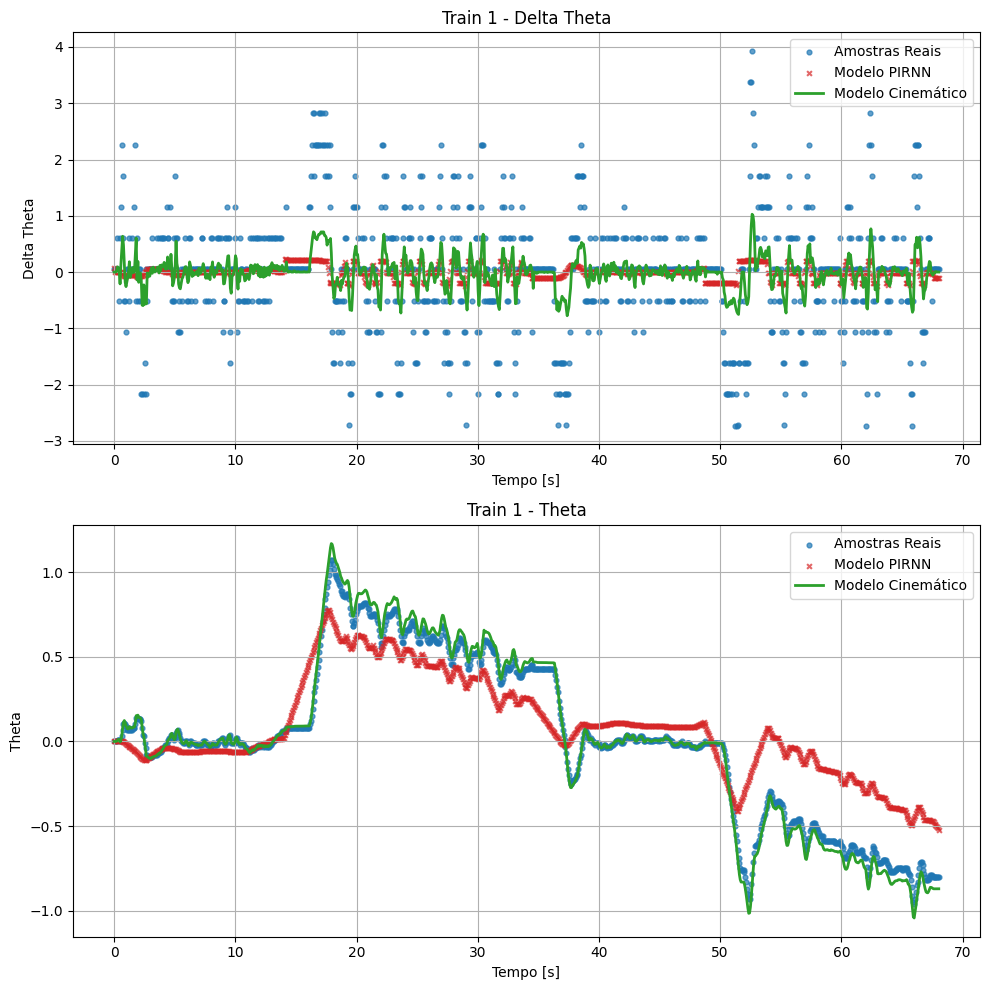

{'Theta': {'MSE': 0.060276124570519354, 'R2': 0.7327335027739624}}


In [19]:
metrics1, q1_pred = EvaluateModel(
    model,
    x_train,
    Train1,
    q,
    "Train 1"
)